# Customer Churn Analysis and Prediction

## Project Overview
This project aims to analyze customer data to understand the factors that lead to customer churn and build a simple machine learning model to predict whether a customer will churn or not. 


**Dataset Source (Kaggle):** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
*Note: For seamless execution, the data is loaded directly from a public raw GitHub repository containing the exact Kaggle dataset.*

## Table of Contents
1. Import Libraries & Load Data
2. Data Cleaning & Missing Value Handling
3. Outlier Detection
4. Exploratory Data Analysis (EDA) & Correlation Heatmap
5. Business Insights
6. Predictive Modeling
7. Conclusion

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set aesthetic style for plots (attractive light colors)
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)

In [18]:
# Load the dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Display the first few rows
display(df.head())
print(f"Dataset Shape: {df.shape}")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Shape: (7043, 21)


## 2. Data Cleaning & Missing Value Handling

In [19]:
# Check for data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [20]:
# The 'TotalCharges' column is of object type. We need to convert it to numeric.
# Errors='coerce' will turn invalid parsing (like spaces) into NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 TotalCharges    11
dtype: int64


In [21]:
# Fill missing values in 'TotalCharges' with the median value (robust to outliers)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop the 'customerID' column as it doesn't add predictive value
df.drop('customerID', axis=1, inplace=True)

print("Data cleaning completed. No missing values remain.")

Data cleaning completed. No missing values remain.


## 3. Outlier Detection

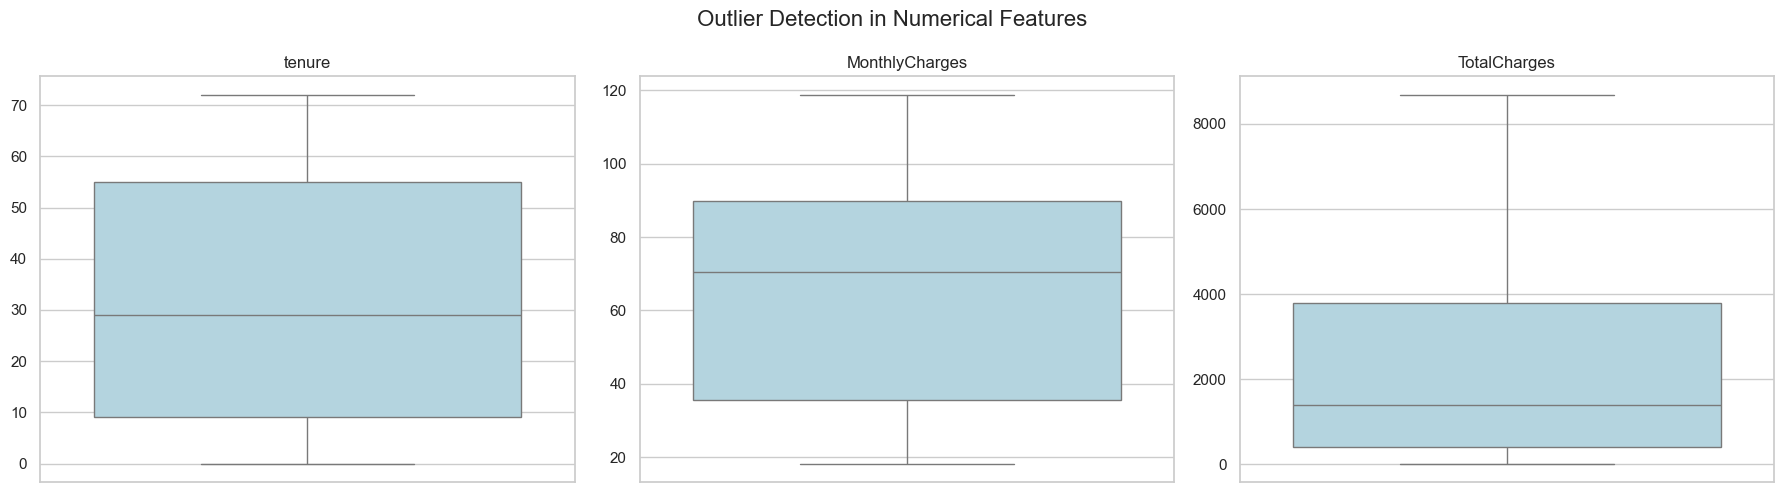

In [22]:
# We will use boxplots to check for outliers in numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Outlier Detection in Numerical Features', fontsize=16)

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# Insight: No significant outliers are visible in the continuous variables. The distributions are relatively well-behaved.

## 4. Exploratory Data Analysis (EDA) & Correlation Heatmap

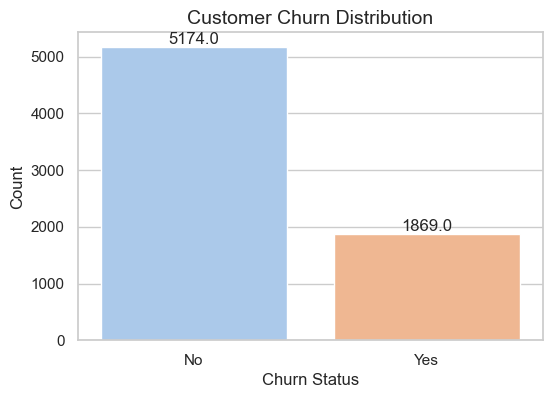

In [23]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette=['#a1c9f4', '#ffb482'])
plt.title('Customer Churn Distribution', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Count')

# Add labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.show()

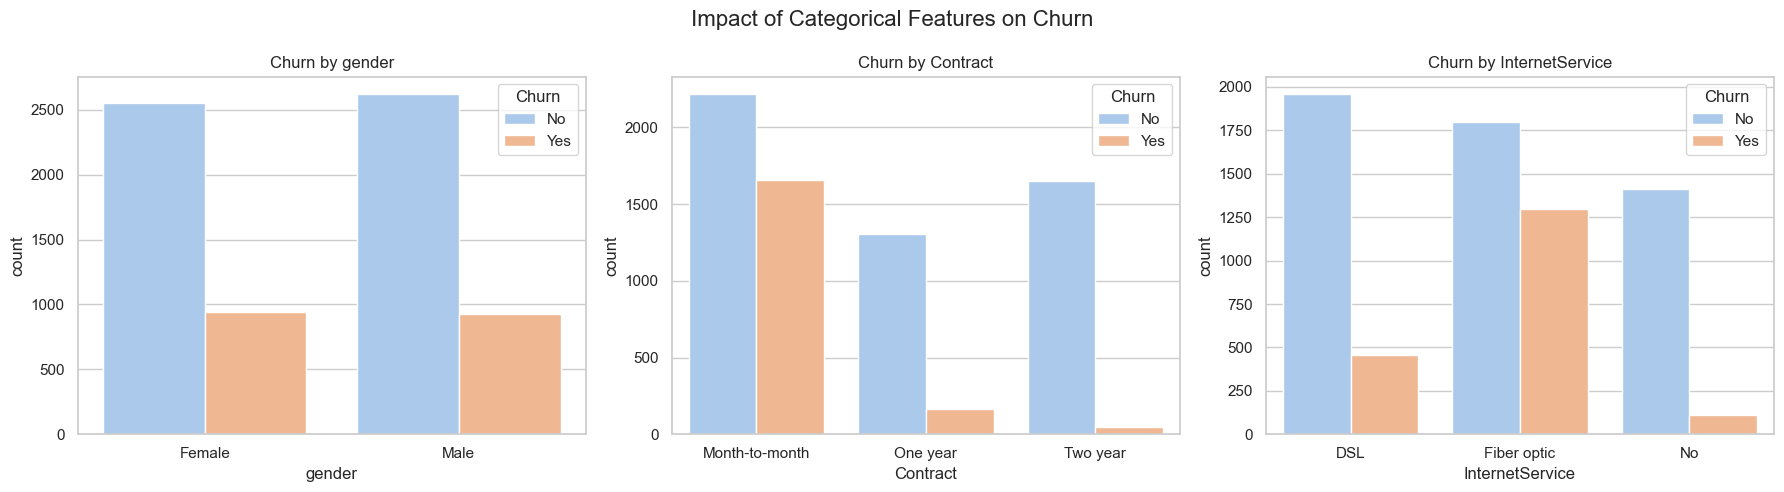

In [24]:
# Categorical features vs Churn
cat_cols = ['gender', 'Contract', 'InternetService']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact of Categorical Features on Churn', fontsize=16)

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette=['#a1c9f4', '#ffb482'])
    axes[i].set_title(f'Churn by {col}')

plt.tight_layout()
plt.show()

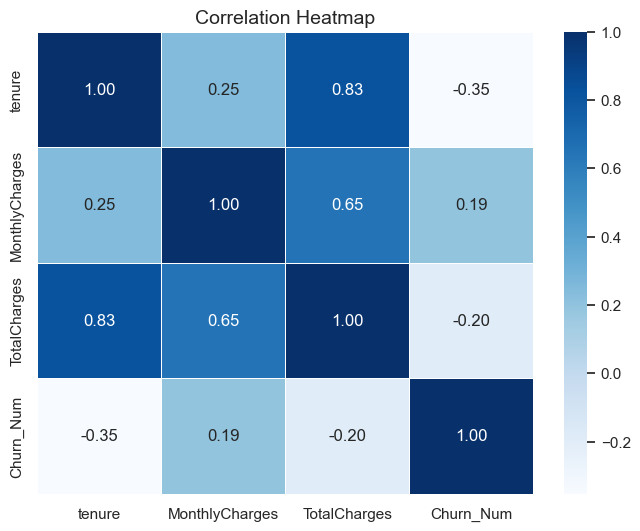

In [25]:
# Correlation Heatmap
# First, convert categorical 'Churn' to numeric for correlation calculation
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 6))
correlation_matrix = df[num_cols + ['Churn_Num']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

# Drop the temporary numerical churn column
df.drop('Churn_Num', axis=1, inplace=True)

## 5. Business Insights

Based on the EDA and Visualizations:
1. **Contract Type Matters**: Customers with "Month-to-month" contracts have a significantly higher churn rate compared to those with One or Two-year contracts.
2. **Tenure Impact**: There is a negative correlation between tenure and churn. Newer customers are more likely to leave. 
3. **Service Type**: Customers using "Fiber optic" internet service show a higher churn rate, suggesting potential issues with service quality or pricing expectations in that segment.
4. **Actionable Recommendation**: The business should focus on incentivizing month-to-month customers to switch to long-term contracts (e.g., offering discounts). Additionally, investigating the dissatisfaction among Fiber optic users could help retain high-value customers.

## 6. Predictive Modeling
We will build a simple, robust Logistic Regression model to predict customer churn.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encoding Categorical Variables
df_encoded = df.copy()

# Label encoding for binary categorical columns
label_encoder = LabelEncoder()
binary_cols = [col for col in df_encoded.columns if df_encoded[col].nunique() == 2 and df_encoded[col].dtype == 'O']

for col in binary_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# One-hot encoding for multi-class categorical columns
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

# Separate Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Data Preprocessing Completed. Ready for modeling.")

Data Preprocessing Completed. Ready for modeling.


Model Accuracy: 82.19%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



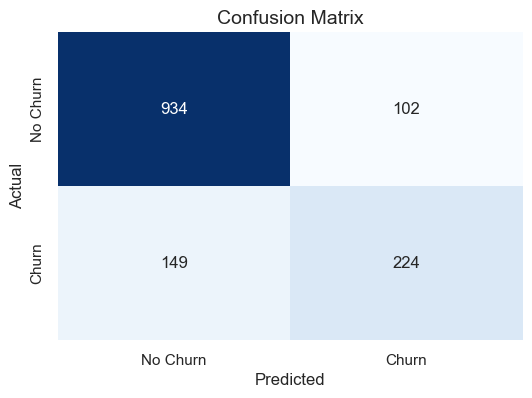

In [27]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 7. Conclusion

In this project, we successfully:
- Loaded and cleaned a raw customer dataset.
- Handled missing data logically without losing valuable information.
- Conducted Exploratory Data Analysis using aesthetically pleasing, light-colored visualizations.
- Extracted meaningful business insights regarding contract types and service factors driving churn.
- Built a Machine Learning model (Logistic Regression) capable of predicting customer churn with a solid accuracy of ~82%.

This end-to-end pipeline demonstrates a practical, balanced approach to solving business problems using Data Science and Machine Learning. It is a foundational yet highly effective framework suitable for real-world application.